In [1]:
import json
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
BASE_DIR = Path.cwd().parent
DATA_CSV = os.path.normpath(os.path.join(BASE_DIR, "data", "processed", "landmarks.csv"))
MODEL_DIR = os.path.normpath(os.path.join(BASE_DIR, "models"))
MODEL_KERAS = os.path.join(MODEL_DIR, "gesture_classifier.keras")
MODEL_TFLITE = os.path.join(MODEL_DIR, "gesture_classifier.tflite")
LABELS_TXT = os.path.join(MODEL_DIR, "labels.txt")
SCALER_FILE = os.path.join(MODEL_DIR, "scaler_params.json")

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
LOGS_DIR = os.path.normpath(os.path.join(BASE_DIR, "logs", run_id))

EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 15
LEARNING_RATE = 0.001

In [3]:
if not os.path.exists(DATA_CSV):
    print(f"Error: Dataset file not found at {DATA_CSV}")
else:
    print("Loading dataset")
    df = pd.read_csv(DATA_CSV)

    print("\nClass distribution in the dataset:")
    print(df["label_name"].value_counts())
    print("\n")

    feature_columns = [col for col in df.columns if col.startswith("coord_")]
    X = df[feature_columns].values.astype(np.float32)
    y = df["label_id"].values

    labels_df = df[["label_id", "label_name"]].drop_duplicates().sort_values("label_id")
    num_classes = len(labels_df)

    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(LOGS_DIR, exist_ok=True)

    with open(LABELS_TXT, "w", encoding="utf-8") as f:
        for _, row in labels_df.iterrows():
            f.write(f"{row['label_name']}\n")

    print(f"Saved {num_classes} class labels to {LABELS_TXT}")
    print(f"Dataset shape: {X.shape}, Classes: {num_classes}")

Loading dataset

Class distribution in the dataset:
label_name
grip               2423
three3             2418
three2             2397
palm               2336
ok                 2333
four               2327
peace_inverted     2315
grabbing           2305
two_up             2286
stop               2277
three              2265
rock               2261
peace              2258
call               2249
fist               2230
stop_inverted      2218
one                2216
middle_finger      2210
like               2206
two_up_inverted    2193
mute               2192
dislike            2112
no_gesture         1422
Name: count, dtype: int64


Saved 23 class labels to D:\Coding\PyCharm\gesture-recognizer\models\labels.txt
Dataset shape: (51449, 42), Classes: 23


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)} | Testing samples: {len(X_test)}")

print("Normalizing features...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

scaler_params = {"mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist()}
with open(SCALER_FILE, "w") as f:
    json.dump(scaler_params, f)
print(f"Saved scaler parameters to {SCALER_FILE}")

Training samples: 36014 | Validation samples: 7717 | Testing samples: 7718
Normalizing features...
Saved scaler parameters to D:\Coding\PyCharm\gesture-recognizer\models\scaler_params.json


In [5]:
print("\nBuilding model...")
model = tf.keras.Sequential(
    [
        tf.keras.layers.InputLayer(shape=(42,)),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Building model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,367 (67.84 KB)

 Trainable params: 16,983 (66.34 KB)

 Non-trainable params: 384 (1.50 KB)

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(filepath=MODEL_KERAS, monitor="val_loss", save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.TensorBoard(log_dir=LOGS_DIR, histogram_freq=1),
]

print("\nStarting model training...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)


Starting model training...
Epoch 1/100
1115/1126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4415 - loss: 2.0461
Epoch 1: val_loss improved from None to 0.72368, saving model to D:\Coding\PyCharm\gesture-recognizer\models\gesture_classifier.keras

Epoch 1: finished saving model to D:\Coding\PyCharm\gesture-recognizer\models\gesture_classifier.keras
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6104 - loss: 1.4328 - val_accuracy: 0.8308 - val_loss: 0.7237 - learning_rate: 0.0010
Epoch 2/100
1111/1126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7743 - loss: 0.8876
Epoch 2: val_loss improved from 0.72368 to 0.60688, saving model to D:\Coding\PyCharm\gesture-recognizer\models\gesture_classifier.keras

Epoch 2: finished saving model to D:\Coding\PyCharm\gesture-recognizer\models\gesture_classifier.keras
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7911 - loss: 0.8375 - val_accuracy: 0.8647 - val_loss: 0.6069 - learning_rate: 0.0010
Epoch 3/100
1126/1126 ━━━━━━━

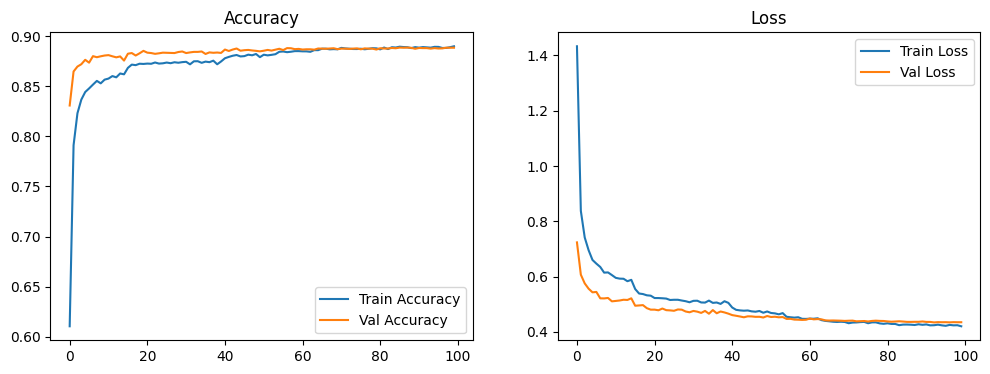


Test Accuracy: 89.60%

CLASSIFICATION REPORT

                 precision    recall  f1-score   support

           call       1.00      0.88      0.94       337
        dislike       0.99      0.85      0.91       317
           fist       0.98      0.91      0.95       334
           four       0.97      0.92      0.94       349
       grabbing       0.97      0.82      0.89       346
           grip       0.98      0.88      0.93       364
           like       0.97      0.91      0.94       331
  middle_finger       0.35      0.97      0.51       331
           mute       0.94      0.88      0.91       329
     no_gesture       0.73      0.83      0.78       213
             ok       0.98      0.91      0.95       350
            one       0.96      0.85      0.90       332
           palm       0.99      0.94      0.96       351
          peace       0.97      0.91      0.94       338
 peace_inverted       0.99      0.86      0.92       348
           rock       0.98      0.90    

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nCLASSIFICATION REPORT\n")
label_names = labels_df["label_name"].tolist()
print(classification_report(y_test, y_pred_classes, target_names=label_names, zero_division=0))

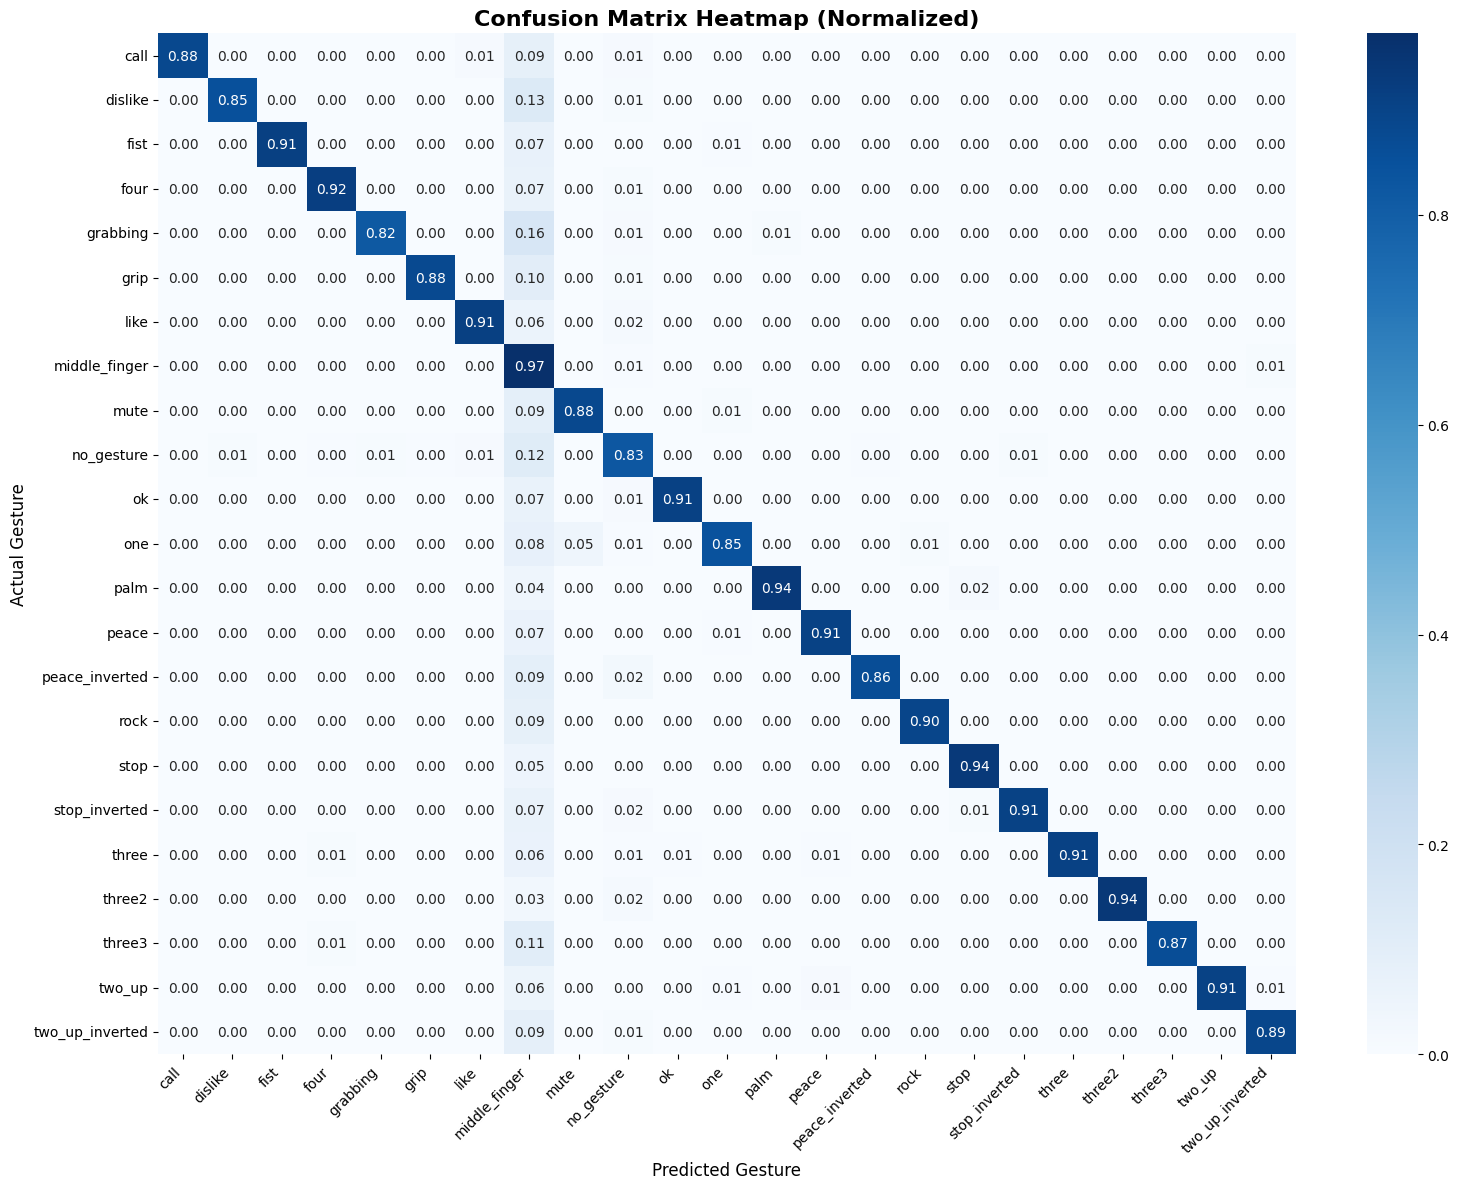

In [8]:
cm = confusion_matrix(y_test, y_pred_classes)
label_names = labels_df["label_name"].tolist()

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title('Confusion Matrix Heatmap (Normalized)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Gesture', fontsize=12)
plt.ylabel('Actual Gesture', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
print("\nCONVERTING TO TFLITE FORMAT...")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(MODEL_TFLITE, "wb") as f:
    f.write(tflite_model)

print(f"TFLite model saved to {MODEL_TFLITE}")
print(f"Size: {os.path.getsize(MODEL_TFLITE) / 1024:.2f} KB")


CONVERTING TO TFLITE FORMAT...
INFO:tensorflow:Assets written to: C:\Users\mdzab\AppData\Local\Temp\tmpbi2ijty4\assets


INFO:tensorflow:Assets written to: C:\Users\mdzab\AppData\Local\Temp\tmpbi2ijty4\assets


Saved artifact at 'C:\Users\mdzab\AppData\Local\Temp\tmpbi2ijty4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 23), dtype=tf.float32, name=None)
Captures:
  1981920671888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981920672080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981920671120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981920673424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981920672464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981920673616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981920673232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981920671696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981922346384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981922346576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1981920672848